# Customer Analysis

This notebook focuses on analyzing customer behavior, customer value, and purchasing patterns.

Objectives:
- Identify high-value customers
- Analyze customer purchase frequency
- Perform RFM Analysis
- Segment customers based on purchasing behavior

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

In [3]:
df = pd.read_csv("../data/processed/online_retail_eda.csv")

C:\Users\M.Bilal\AppData\Local\Temp\ipykernel_3384\1974453864.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/online_retail_eda.csv")


In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,Year,Month,Hour,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009,12,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009,12,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009,12,7,Tuesday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 14 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007913 non-null  object 
 1   StockCode    1007913 non-null  object 
 2   Description  1007913 non-null  object 
 3   Quantity     1007913 non-null  int64  
 4   InvoiceDate  1007913 non-null  object 
 5   Price        1007913 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007913 non-null  object 
 8   Revenue      1007913 non-null  float64
 9   YearMonth    1007913 non-null  object 
 10  Year         1007913 non-null  int64  
 11  Month        1007913 non-null  int64  
 12  Hour         1007913 non-null  int64  
 13  DayOfWeek    1007913 non-null  object 
dtypes: float64(3), int64(4), object(7)
memory usage: 107.7+ MB


In [6]:
df.shape

(1007913, 14)

## Dataset Overview

The dataset contains cleaned retail transaction records with customer, product, and revenue information.

In [7]:
total_customers = df['Customer ID'].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 5,878


In [8]:
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £20,476,260.45


In [9]:
avg_revenue_customer = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .mean()
)

print(f"Average Revenue per Customer: £{avg_revenue_customer:,.2f}")

Average Revenue per Customer: £2,955.90


## Customer KPIs

These metrics provide a high-level view of customer contribution to overall business revenue.

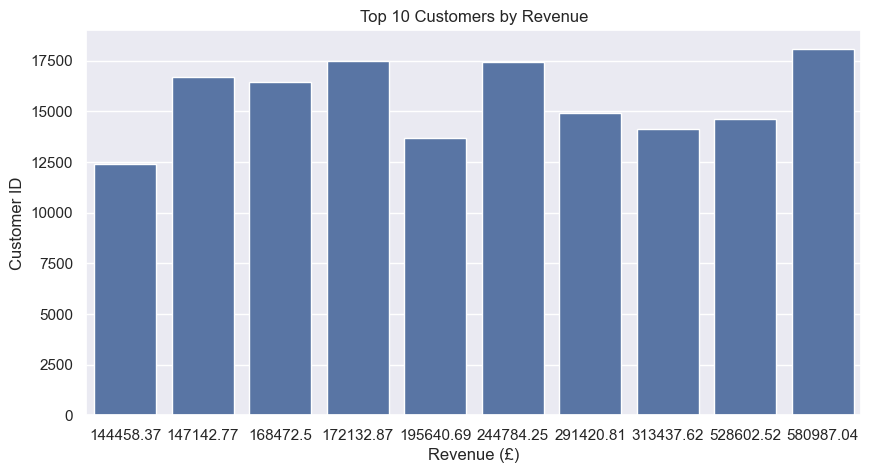

In [10]:
top_customers = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.show()

### Insight

- A small number of customers generate a significant portion of total revenue.
- These customers can be considered high-value customers.
- Retaining such customers is important for business growth.

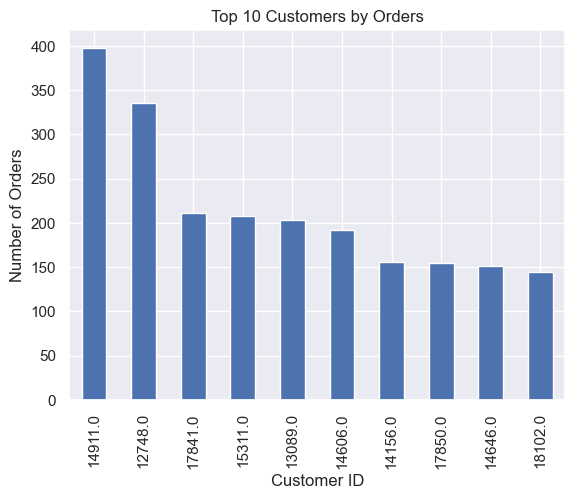

In [11]:
top_orders = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

top_orders
top_orders.plot(kind="bar")

plt.title("Top 10 Customers by Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.show()

### Most Active Customers

These customers place orders most frequently.

High-frequency customers indicate strong engagement and represent valuable long-term business relationships.

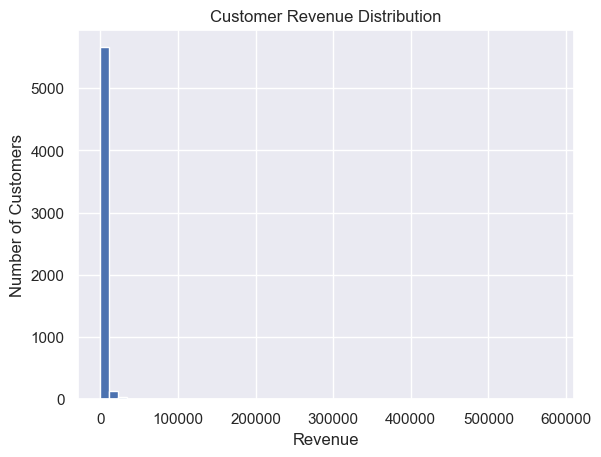

In [12]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
)

customer_revenue.hist(bins=50)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")

plt.show()

### Revenue Distribution

Most customers generate relatively small revenue amounts, while a small number of customers contribute disproportionately large revenue.

This pattern follows a typical Pareto distribution often seen in retail businesses.

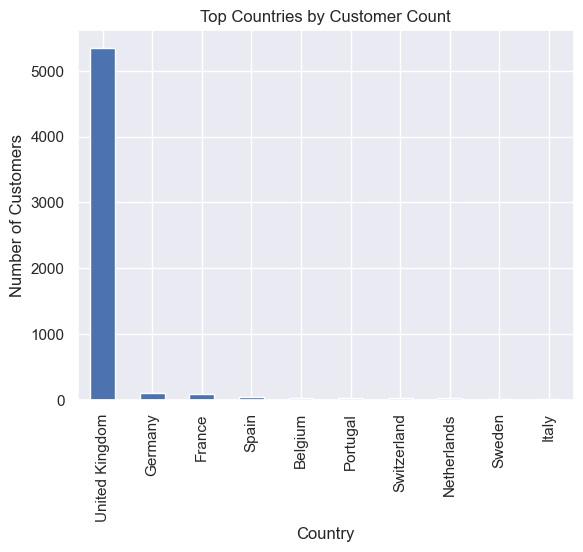

In [13]:
country_customers = (
    df.groupby("Country")["Customer ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

country_customers
country_customers.plot(kind="bar")

plt.title("Top Countries by Customer Count")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.show()

### Geographic Customer Distribution

The business serves customers across multiple countries.

The chart highlights the countries with the largest customer base.

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [15]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289724,2955.904095
std,209.338707,13.009830,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [16]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


### RFM Summary Statistics

The RFM table summarizes customer behavior using:

- Recency: Days since the customer's last purchase.
- Frequency: Number of unique orders placed.
- Monetary: Total revenue generated by the customer.

These metrics help identify valuable and loyal customers.

In [17]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,326,12,77556.46,2,5,5
12347.0,2,8,4921.53,5,4,5
12348.0,75,5,2019.40,3,4,4
12349.0,19,4,4428.69,5,3,5
12350.0,310,1,334.40,2,1,2


In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,255
12347.0,2,8,4921.53,5,4,5,545
12348.0,75,5,2019.40,3,4,4,344
12349.0,19,4,4428.69,5,3,5,535
12350.0,310,1,334.40,2,1,2,212


### RFM Scoring

Customers are assigned scores from 1 to 5 for Recency, Frequency, and Monetary value.

Higher scores indicate better customer engagement and value.

In [19]:
def customer_segment(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Others"


rfm["Segment"] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,At Risk
12347.0,2,8,4921.53,5,4,5,545,Champions
12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
12349.0,19,4,4428.69,5,3,5,535,Loyal Customers
12350.0,310,1,334.40,2,1,2,212,Others


<Axes: xlabel='Segment'>

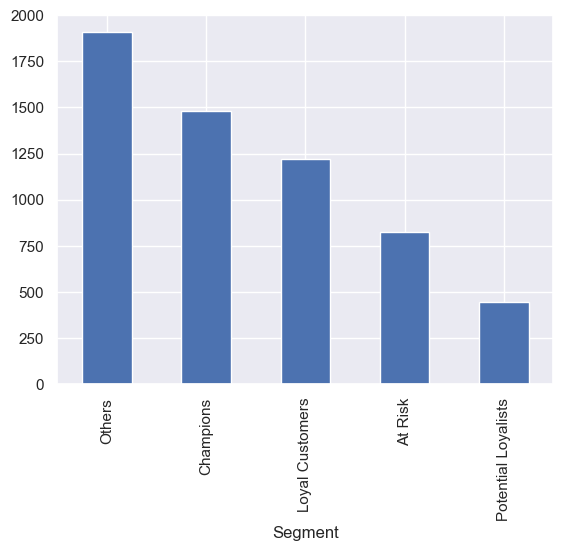

In [20]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

segment_counts.plot(
    kind="bar"
)
# plt.title("Customer Segments")
# plt.xlabel("Segment")
# plt.ylabel("Number of Customers")

# plt.xticks(rotation=45)

# plt.show()

### Customer Segment Distribution

The customer base was divided into five segments using RFM analysis.

The largest group belongs to the "Others" category, followed by "Champions" and "Loyal Customers".

A substantial number of customers are classified as Champions, indicating a strong base of highly engaged and valuable customers.

The presence of At Risk customers highlights an opportunity for retention campaigns to prevent customer churn.

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Champions'),
  Text(1, 0, 'Loyal Customers'),
  Text(2, 0, 'At Risk'),
  Text(3, 0, 'Others'),
  Text(4, 0, 'Potential Loyalists')])

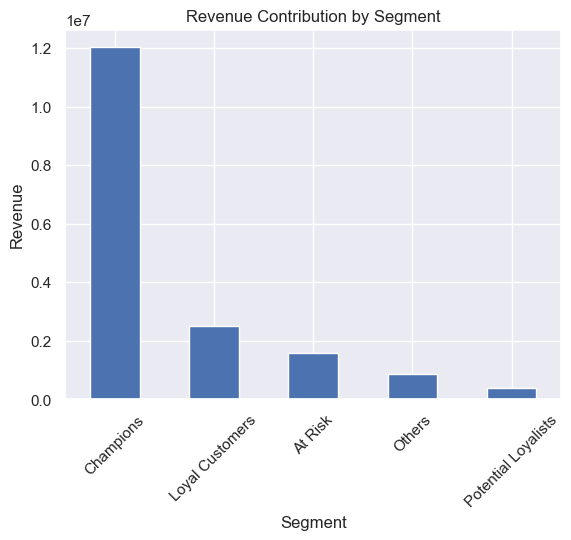

In [21]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue
segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

# plt.show()

### Revenue Contribution by Customer Segment

Champions generate the highest revenue contribution, accounting for the majority of total sales.

Loyal Customers represent the second most valuable segment and provide a stable revenue stream.

At Risk customers still contribute significant revenue, suggesting that re-engagement strategies could recover valuable customers before they become inactive.

Potential Loyalists currently contribute less revenue but represent future growth opportunities if nurtured effectively.

In [22]:
rfm.to_csv(
    "../data/processed/customer_rfm.csv"
)

### Key Customer Insights

- Champions are the most valuable customer segment and generate the largest share of revenue.
- Loyal Customers consistently contribute to business performance and should be retained through loyalty programs.
- At Risk customers still represent significant revenue and should be targeted through personalized retention campaigns.
- Potential Loyalists offer growth opportunities and can be converted into long-term customers through engagement strategies.
- The business revenue is highly concentrated among a relatively small group of high-value customers, demonstrating a Pareto-like customer distribution.

In [23]:
rfm['Segment'].value_counts()

Segment
Others                 1908
Champions              1482
Loyal Customers        1221
At Risk                 824
Potential Loyalists     443
Name: count, dtype: int64